# Forest plots

A **forest plot** is a graphical summary commonly used in medical research, particularly in meta-analyses and clinical trials, to display estimates from multiple studies or subgroups. It provides a compact visualisation of the point estimates (e.g. risk ratios, odds ratios, mean differences) and their associated confidence intervals, often aligned along a shared axis to facilitate comparison.

Each row in a forest plot typically represents a study or the result of a single analysis. A central marker (such as a dot or square) indicates the effect estimate, while a horizontal line represents its confidence interval, usually at the 95% level. A vertical reference line — often placed at 1 for ratio measures or 0 for absolute differences — indicates the null effect. Estimates crossing this line suggest statistical non-significance.

In this notebook, we explore the construction of forest plots from tabular data, and demonstrate how to customise aesthetics, include group labels, and add annotation panels or supplementary tables.


In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plot_misc.forest as forest
import plot_misc.example_data.examples as examples
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from plot_misc import utils as plm_utils
from plot_misc.utils.utils import annotate_axis_midpoints

In [2]:
# import example data
combined = examples.load_forest_data()
combined.reset_index(drop=True, inplace=True)

# constants
CMTOINCH = 1/2.54
SHAPE_DICT = {'PGS only': 'o', 'PGS plus': 's', 'PGS extended': 'H'}
COL_DICT = {'wo T2DM/CVD': 'orangered', 'w T2DM': 'blueviolet',
              'w T2DM & CVD': 'limegreen'}
STRING_COL = 'string'

# add y-axis values
combined.sort_values(['evaluated_outcome','subgroup_name'],  inplace=True)
sort_dict = {'CVD + AF + HF': 0, 'CVD': 1, 'CHD': 2, 'Ischaemic Stroke': 5,
             'HF': 3, 'AF': 4}
combined = forest.set_y_coordinates(combined, group='evaluated_outcome', strata_within_group='model',
                                    sort_dict=sort_dict, between_pad=6,  
                                   )          
# add colours and shape
combined['col'] = combined.subgroup_name.map(COL_DICT)
combined['shape'] = combined.model.map(SHAPE_DICT)

# select a single 'study'
single = combined[combined.model=='PGS only'].copy()
single[STRING_COL] =\
    [plm_utils.formatting.format_estimates(p, lower=l, upper=u, round=2, exp=False) \
     for p,l,u in zip(single['test_cstatistic'], single['test_cstatistic_lb'], single['test_cstatistic_ub'])]



# show updated table
print(f'combined:\n {combined.head()}')
print('\n\n')
print(f'single:\n {single.head()}')


combined:
    evaluated_outcome subgroup_name  test_cstatistic  test_cstatistic_lb  \
37     CVD + AF + HF        w T2DM         0.664739            0.663927   
36     CVD + AF + HF  w T2DM & CVD         0.633322            0.632141   
38     CVD + AF + HF   wo T2DM/CVD         0.748235            0.747981   
1      CVD + AF + HF        w T2DM         0.608193            0.607368   
0      CVD + AF + HF  w T2DM & CVD         0.613562            0.612361   

    test_cstatistic_ub         model  y_axis         col shape  
37            0.665552  PGS extended     1.0  blueviolet     H  
36            0.634502  PGS extended     3.0   limegreen     H  
38            0.748489  PGS extended     5.0   orangered     H  
1             0.609018      PGS only     1.0  blueviolet     o  
0             0.614764      PGS only     3.0   limegreen     o  



single:
   evaluated_outcome subgroup_name  test_cstatistic  test_cstatistic_lb  \
1     CVD + AF + HF        w T2DM         0.608193            

## Complex Forest Plot
To illustrate the flexibility of this module we will start with a rather complex forest plot with multiple values on the same line and the confidence interval 
presented within the shape.

This is the span dictionary:
{0: {'min': np.float64(1.0), 'max': np.float64(8.0), 'kwargs': {'color': 'white', 'zorder': 0}}, 1: {'min': np.float64(8.0), 'max': np.float64(18.0), 'kwargs': {'color': 'lightgrey', 'zorder': 0}}, 2: {'min': np.float64(18.0), 'max': np.float64(28.0), 'kwargs': {'color': 'white', 'zorder': 0}}, 3: {'min': np.float64(28.0), 'max': np.float64(38.0), 'kwargs': {'color': 'lightgrey', 'zorder': 0}}, 4: {'min': np.float64(38.0), 'max': np.float64(48.0), 'kwargs': {'color': 'white', 'zorder': 0}}, 5: {'min': np.float64(48.0), 'max': np.float64(57.0), 'kwargs': {'color': 'lightgrey', 'zorder': 0}}}


/home/amand/google_drive/Research/plot-misc/plot_misc/forest.py:497: RuntimeWarning: `1` not found in `data`, creating `a_col` column with value `1`.
  warnings.warn(f"`{cn}` not found in `data`, creating `{n_cn}` "


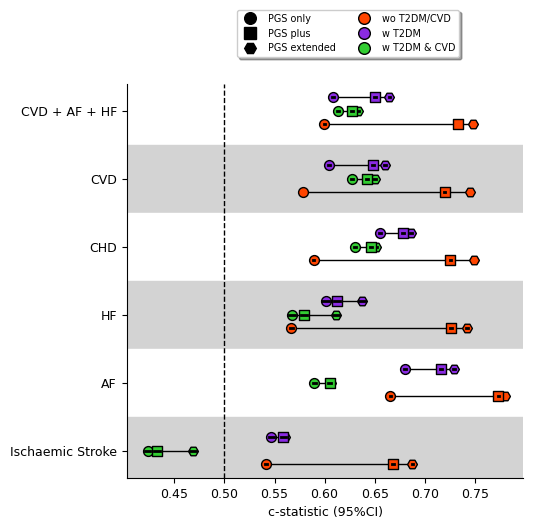

In [3]:
# figure
f, ax = plt.subplots(1, figsize=(13*CMTOINCH, 13*CMTOINCH))
forest1 = forest.ForestPlot(data=combined, x_col='test_cstatistic', lb_col='test_cstatistic_lb',
                           ub_col='test_cstatistic_ub', g_col='evaluated_outcome',
                           ax=ax, ) 
_, ax = forest1.plot(s_col='shape', c_col='col', s_size_col= 50, ci_colour='black',  
                     connect_shape=True, ylim=(-1,57),
                     kwargs_scatter_dict={'edgecolors':'black'},
                     kwargs_connect_segments_dict={'zorder':1},
                     verbose=True,
                    )

# Add plot look
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('c-statistic (95%CI)', fontsize=9)
ax.tick_params('both', labelsize=9)
ax.axvline(0.5, linewidth=1, linestyle='--', c='black')

# legend
SHAPE_val = list(SHAPE_DICT.values())
SHAPE_key = list(SHAPE_DICT.keys())
COL_val = list(COL_DICT.values())
COL_key = list(COL_DICT.keys())
leg_handles = []

for i in range(len(SHAPE_key)):
    leg_handles = leg_handles +  [
        Line2D([0], [0], marker=SHAPE_val[i], color='black',
               markersize=14, lw=0.0, label=SHAPE_key[i]
              )
    ]

for i in range(len(COL_key)):
    leg_handles = leg_handles +  [
        Line2D([0], [0], marker='o', color=COL_val[i],
               markersize=14, markeredgecolor='black', lw=0,
               label=COL_key[i]
              )
    ]

ax.legend(handles=leg_handles , ncol=2, bbox_to_anchor=(0.85, 1.20),
          fancybox=True, shadow=True, fontsize='x-small', markerscale=0.6
         )
# printing the span parameters. 
print('This is the span dictionary:')
print(forest1.span_dict)

## Classic forest plot

Next we will use the same function to depict a more classical forest plot with a single estimate and confidence interval on each line. Note that due to the study sample size the confidence are very small and plotting the confidence interval _on top_ of the shape will  look better (see the `zorder` parameter). 

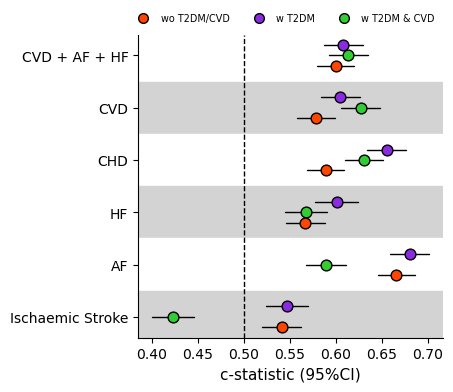

In [4]:
# increasing the ci to better showcase the function
single['test_cstatistic_lb'] = single['test_cstatistic_lb'] - 0.02
single['test_cstatistic_ub'] = single['test_cstatistic_ub'] + 0.02

# figure
f, ax = plt.subplots(1, figsize=(10*CMTOINCH, 10*CMTOINCH))
forest2 = forest.ForestPlot(data=single, x_col='test_cstatistic', lb_col='test_cstatistic_lb',
                             ub_col='test_cstatistic_ub', g_col='evaluated_outcome', ax=ax,)
_, ax = forest2.plot(s_col='shape', c_col='col', ci_colour='black', s_size_col= 60, ci_lwd=1,
                     ylim=(-1,57),
                     kwargs_scatter_dict={'edgecolors':'black'},
                     # plotting the confidence intervals behind the dots, and rounding the lines ends
                     kwargs_plot_ci_dict={'zorder':1, 'solid_capstyle':'round', 'linestyle':'-'} 
                    )

# change format
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('c-statistic (95%CI)', fontsize=11)
ax.tick_params('both', labelsize=10)
ax.axvline(0.5, linewidth=1, linestyle='--', c='black')

# legend
COL_val = list(COL_DICT.values())
COL_key = list(COL_DICT.keys())
leg_handles = []

for i in range(len(COL_key)):
    leg_handles = leg_handles +  [
        Line2D([0], [0], marker='o', color=COL_val[i],
               markersize=14, markeredgecolor='black', lw=0,
               label=COL_key[i]
              )
    ]

ax.legend(handles=leg_handles , ncol=3, bbox_to_anchor=(1.00, 1.10),
          frameon=False, fontsize='x-small', markerscale=0.5
         )

### Add side table
A side table with additional annotations can be added using a custom function and by splitting the figure into two panels with `gridspec`. In this example, we display the numerical values that underpin the bar chart. In other applications, the table could instead show alternative or supplementary information, depending on the context. 

To ensure the coloured span persists between panels this will be extracted from the forest object and passed to the `plot_table` function. 

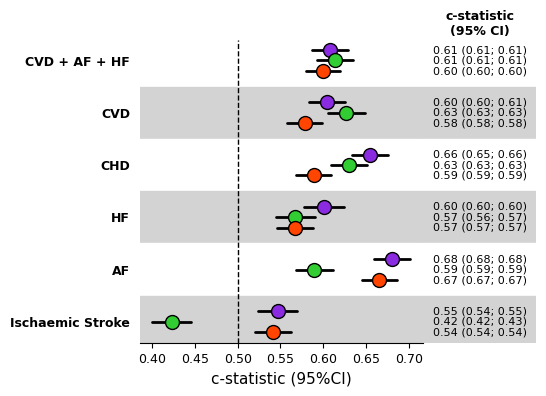

In [5]:
# create subplot and remove space
f, ax = plt.subplots(1, ncols=2, figsize=(13*CMTOINCH, 10*CMTOINCH),
                     gridspec_kw={'width_ratios': [10,4]},
                     sharey=False,
                     )
plt.subplots_adjust(wspace=0)

# add forest plot
forest3 = forest.ForestPlot(data=single, x_col='test_cstatistic',
                            lb_col='test_cstatistic_lb',
                            ub_col='test_cstatistic_ub',
                            g_col='evaluated_outcome', 
                            ax=ax[0],
                           )
_, _ = forest3.plot(s_col='shape', c_col='col', ci_colour='black',
                     s_size_col= 100, ci_lwd=2, ylim=(-1, 57),
                     kwargs_scatter_dict={'edgecolors':'black'},
                     kwargs_plot_ci_dict={'zorder':1, 'solid_capstyle':'round', 'linestyle':'-'}
                          )
ax[0].spines[['right', 'left', 'top']].set_visible(False)
ax[0].set_xlabel('c-statistic (95%CI)', fontsize=11)
ax[0].tick_params('both', labelsize=9, left=False)
ax[0].yaxis.set_ticklabels(ax[0].yaxis.get_ticklabels(),
                           weight='bold', size=9,
                          )
ax[0].axvline(0.5, linewidth=1, linestyle='--', c='black')

# add side-table
ax[1].set_ylim(ax[0].get_ylim())
span = forest3.span_dict
_ = forest.plot_table(single, annoteheader='c-statistic\n(95% CI)',
                  string_col=STRING_COL, ax=ax[1],
                  halignment_text='center',
                  halignment_header='center',
                  xloc_header=0.5,
                  size_text=8, size_header=9,
                  negative_padding=3,
                  span=span,
                  )


### Multi-panel forest plot

Next, we will use this repository to create a multi-panel forest plot with side tables for the effect estimates and interaction p-values. For this, we will use a table containing hazard ratios for a standard deviation increase in LDL-C or Apo-B, and its association with major adverse cardiovascular events (MACE).

Because we are working with a rather complicated plot, involving multiple subgroup analyses, we will add section headers using a small helper function (`annotate_axis_midpoints`). Additionally, since we are plotting hazard ratios, we will need to perform all plotting on the natural log scale and back-transform the tick labels at locations that yield neatly rounded values. For this we will use `change_ticks`.

You will notice that only a fraction of the code is functional in the sense that it pertains directly to the plotting steps. Most of the code is either focused on the layout of the panels or on the plotting aesthetics. These are all intentionally left to matplotlib so that `plot-misc` can be used seamlessly within existing matplotlib codebases, while also benefiting from the extensive functionality matplotlib offers.

_Note_: we are passing `Comparison` to `set_y_coordinates` and `Model` to `col_g` in the plotting function. This is done so that we can group by comparison but still have dot specific y-axis labels. This does mess-up the span placement which have been turned off for that reason. An alternative would be to pas `Comparison` to each function and manually replace the y-axis tick locations and labels afterwards.

In [6]:
# fist getting some data and defining some constants
data_mace = examples.load_mace_associations()
BETWEEN_PAD = 4
POINT = 'coef'
LB = 'coef lower 95%'
UB = 'coef upper 95%'
YLABEL = 'Model'
CI_SIZE=0.80
EDGECOLOUR='black'
TICK_LABEL_SIZE = 8
TITLE_SIZE = 5
TICK_LENGTH = 2.5
TEXT_SIZE = 7

data_mace[[POINT, LB, UB, YLABEL, 'Comparison']].head()

,coef,coef lower 95%,coef upper 95%,Model,Comparison
model,,,,,
LDL-C (mmol/L): Model 2,0.019086,0.007960,0.030212,Overall,Total (adjusted)
LDL-C (mmol/L): Model 3,0.016317,0.004830,0.027804,wo ASCVD,ASCVD history
LDL-C (mmol/L): Model 4,-0.029044,-0.069279,0.011190,w ASCVD,ASCVD history
LDL-C (mmol/L): Model 5,0.016440,0.004910,0.027969,wo T2DM,T2DM history
LDL-C (mmol/L): Model 6,0.001776,-0.037393,0.040944,w T2DM,T2DM history


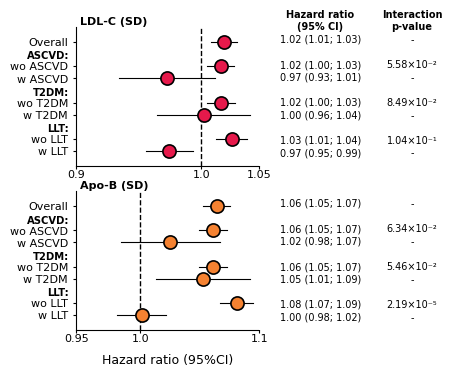

In [7]:
# For the actual plotting we will use a dictionary to define the shape and order of the panels. 
# order of the panels: two rows, with each three column for the actual forest plot and for the two side tables.
#  the values include the panel indices and the x-axis tick locations.
order_map = {
    'LDL-C (mmol/L)': [(0,0),(0,1),(0,2),[0.90,1.00,1.05]],
    'Apo-B (g/L)': [(1,0),(1,1),(1,2),[0.95,1.00,1.10]],
}

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# STEP 1
# creating a figure with gridspec panels. 
fig = plt.figure(figsize=(12*CMTOINCH, 10*CMTOINCH))
gs = GridSpec(nrows=2, ncols=3,
              # height_ratios=heights,
              width_ratios=[6, 4.0, 2,],
              figure=fig, wspace=0.00, hspace=0.18)

# initiating the ax object
ax = None
# looping over the order_map object and extracting the relevant subsets of data from `data_mace`
for title, idx_list in order_map.items():
    # forest plot axis index
    idx = idx_list[0] 
    # estimates axis index
    idx_tab1 = idx_list[1]
    # p-value axis index
    idx_tab2 = idx_list[2]
    # the x-axis tick locations
    xaxis_lab = idx_list[3]
    # getting the axes
    ax = fig.add_subplot(gs[idx])
    ax_tab1 = fig.add_subplot(gs[idx_tab1])
    ax_tab2 = fig.add_subplot(gs[idx_tab2])
    # subsetting the data on the exposure
    sub = data_mace[data_mace['Exposure'] == title].reset_index()
    # getting xy coordinates and adding some padding between groups
    sub_c = forest.set_y_coordinates(
        sub, group='Comparison', between_pad=BETWEEN_PAD,
        within_pad=2,
    )
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # STEP 2 plotting the forest plot
    forest_obj = forest.ForestPlot(
        data=sub_c, x_col=POINT, lb_col=LB, ub_col=UB, g_col=YLABEL,
        ax=ax,
    )
    forest_obj.plot(c_col='col',s_size_col=90, ci_lwd=CI_SIZE, ci_colour='black',
                    span=False,
                    reverse_y=True, 
                    kwargs_scatter_dict=\
                    {'edgecolors':EDGECOLOUR, 'linewidth':1.2, 'zorder':2},
                    kwargs_plot_ci_dict={'zorder':0},
    )
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # STEP 3 add side table 1
    ax_tab1.set_ylim(ax.get_ylim())
    header = ''
    if idx[0] == 0:
        header = 'Hazard ratio\n(95% CI)'
    else: 
        header = ''
    #span1 = forest_obj.span_dict
    _ = forest.plot_table(sub_c, annoteheader=header,
                      string_col='string_estimates', ax=ax_tab1,
                      halignment_text='center',
                      halignment_header='center',
                      size_text=TEXT_SIZE, size_header=TEXT_SIZE,
                      negative_padding=1,
                         )
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # STEP 4 add side table 2
    ax_tab2.set_ylim(ax.get_ylim())
    header = ''
    if idx[0] == 0:
        header = 'Interaction\np-value'
    _ = forest.plot_table(sub_c, annoteheader=header,
                      string_col='string_interaction_pval', ax=ax_tab2,
                      halignment_text='center',
                      halignment_header='center',
                      size_text=TEXT_SIZE, size_header=TEXT_SIZE,
                      negative_padding=1,
                         )
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # STEP 5 making it all look a bit better
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    # reference line
    ax.axvline(0, linewidth=1, linestyle='--', c='black',
                 zorder=0)
    # #### subgroup section titles 
    headers = ['ASCVD:', 'T2DM:', 'LLT:']
    _ = annotate_axis_midpoints(
        ax=ax, labels=headers, axis='y', gap=BETWEEN_PAD,
        offset=-0.04, padding = 0.35,
        text_kwargs={'fontsize': TICK_LABEL_SIZE*0.9,
                     'fontweight': 'bold',}
                     )
    # ##### setting axes limits and ticks
    ax.set_xticks([])
    ax.set_xticklabels([])
    old_ylim = ax.get_ylim()
    ax.set_ylim(old_ylim[0]+0.5, old_ylim[1]-0.5)
    ax.set_xlim(np.log((xaxis_lab[0], xaxis_lab[-1])))
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE, length=TICK_LENGTH)
    ax.tick_params(axis='x', labelsize=TICK_LABEL_SIZE, length=TICK_LENGTH,
                     pad=0.5)
    # making sure the tick labels are on the HR scale, but the tick positions are on the log scale
    plm_utils.utils.change_ticks(ax, ticks=xaxis_lab, log=True)
    if idx[0] == 1:
        ax.set_xlabel('Hazard ratio (95%CI)',
                      fontsize=9, labelpad=7)
    # #### add title
    new_title = re.sub(r'\((.*?)\)', r'(SD)', title)
    ax.set_title(new_title, loc='left', y=1.01, x=0.02, fontsize=8, pad=0.5,
                   fontdict={'fontweight': 'bold'})
    # NOTE: this can be further improved by decreasing the distance between the side tables and the main plot using
    # `set_zorder` to determine which axes object is on top and `ax.getposition`, `ax.set_position` to move the axes 
    # together 

# Tree plots

Instead of plotting a forest of estimates, we can use tree plots to illustrate individual estimates and the parameter space which is supported by the observed data. Essentially this depicts the confidence interval empirical coverage across a range of values between 0 and 1. 


Text(0.32, 0.4, 'Excludes an\nHR of 1.25')

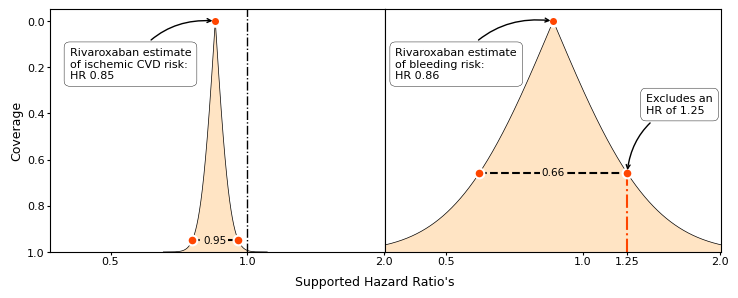

In [8]:
COL1='orangered'
COL2='white'
COL3='bisque'
TICK_LABEL_SIZE = 8
TITLE_SIZE = 5
ANNOT_LINE_WIDTH=1
ARROW_SCALE=7
MARKER_EDGE_SIZE=4
TICK_LENGTH = 2.5
AFONTSIZE=8
NEW_XAXIS=[ 0.50, 1.0, 1.50, 2.0, ]
STRING='string'
XLAB='HR (95%CI)'

ESTIMATES = list(np.log([0.85, 0.86]))
SE = list(np.divide([(np.log(0.96) - np.log(0.76)), (np.log(1.87) - np.log(0.40))], 3.92))
ALPHA=list(np.linspace(1, 0.00001, 10000))
NEW_XAXIS=[0.35, 0.50, 1.00, 2.00]
NEW_XAXIS=[NEW_XAXIS, NEW_XAXIS+[1.25]]
XMIN=np.log(0.86)-0.85
XMAX=np.log(0.86)+0.85
# the 0.65795 indicates the point the ub is less than 1.25
Y125=0.342041
UB125=0.6579592169216922
ANNOT_CI=[[0.95], [UB125]]

# plotting
f, ax = plt.subplots(1, ncols=2, figsize=(22*CMTOINCH, 8*CMTOINCH),
                     gridspec_kw={'width_ratios': [1,1],
                                  'wspace':0},
                     sharey=False,
                     )
for i, _ in enumerate(ax):
    space=forest.EmpericalSupport(estimate=ESTIMATES[i], standard_error=SE[i],
                                  alpha=ALPHA)
    _, _ = space.plot_tree(
        annotate_estimate=True, annotate_ci=ANNOT_CI[i],
        area_c='bisque',
        # support='compatibility',
        ax=ax[i],
        # line arguments
        linewidth=0.5,
        # dot arguments
        estimate_c=COL1, estimate_size=50, kwargs_dot={'edgecolor':COL2, 'linewidth':2},
        # area arguments
        area_a=1.00,
        # argument for the horizontal text
        kwargs_text={'fontsize':7.5, 'backgroundcolor':COL3,
                     'bbox':{'facecolor':COL3, 'alpha':1.00,
                             'edgecolor':'none', 'pad':1}},
        # arguments for the horizontal line
        kwargs_segment={'linestyle':'--', 'linewidth':1.5,
                        'markersize':7, 'markeredgewidth':1.5,
                        'markeredgecolor':COL2}
    )
    # axes
    plm_utils.utils.change_ticks(ax[i], ticks=NEW_XAXIS[i], log=True)
    ax[i].set_xlim(XMIN, XMAX)
    ax[i].tick_params(axis='x', labelsize=TICK_LABEL_SIZE, length=TICK_LENGTH,
                      pad=0.5)
    ax[i].set_xlabel(None)
    ax[i].set_ylim(1.0, ax[i].get_ylim()[1])

# ###### add a vertical line
ax[0].axvline(0.0, linewidth=1.0, linestyle='-.', c='black')
ax[1].axvline(np.log(1.25),  linewidth=1.5, ymax=Y125,
              linestyle='-.', c=COL1, zorder=1)
# ##### Working on a specific axis
ax[0].set_ylabel(ax[0].get_ylabel(), fontsize=9, labelpad=3.0,)
ax[0].tick_params(axis='y', labelsize=TICK_LABEL_SIZE, length=TICK_LENGTH,
                  pad=1.0,)
ax[1].set_yticks([])
ax[1].set_yticklabels([])
ax[1].set_ylabel(None)
# ##### Common label
f.text(0.5, 0.005, "Supported Hazard Ratio's", ha='center',
         fontsize=9)
# #### Annotations
ax[0].annotate( 'Rivaroxaban estimate\nof ischemic CVD risk:\nHR {}'.\
               format(np.exp(ESTIMATES[0])),
               xy=(ESTIMATES[0], 0), xytext=(-0.9, 0.25),
               fontsize=AFONTSIZE,
               arrowprops=dict(
                   arrowstyle='->', connectionstyle='arc3,rad=-0.3',
                   linewidth=ANNOT_LINE_WIDTH, mutation_scale=ARROW_SCALE,
               ),
               bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=1.0,
                         linewidth=0.3, edgecolor='black',
                         )
               )
ax[1].annotate( 'Rivaroxaban estimate\nof bleeding risk:\nHR {}'.\
               format(np.exp(ESTIMATES[1])),
               xy=(ESTIMATES[1], 0), xytext=(-0.95, 0.25),
               fontsize=AFONTSIZE,
               arrowprops=dict(
                   arrowstyle='->', connectionstyle='arc3,rad=-0.3',
                   linewidth=ANNOT_LINE_WIDTH, mutation_scale=ARROW_SCALE,
               ),
               bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=1.0,
                         linewidth=0.3, edgecolor='black',
                         )
               )

ax[1].annotate( 'Excludes an\nHR of 1.25'.\
               format(np.exp(ESTIMATES[1])),
               xy=(np.log(1.25), 1-Y125), xytext=(0.32, 0.40),
               fontsize=AFONTSIZE,
               arrowprops=dict(
                   arrowstyle='->', connectionstyle='arc3,rad=0.3',
                   linewidth=ANNOT_LINE_WIDTH, mutation_scale=ARROW_SCALE,
               ),
               bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=1.0,
                         linewidth=0.3, edgecolor='black',
                         )
               )

